## Experimentation Notebook (extension & experimentation from the NTU paper)

This notebook aims to cover the different permutations of the evacuation model, beyond what is tested in the FYP paper. The FYP paper is a good baseline & captures the data & simulation well, but doesn't take into account big events (no. of agents are fixed), tendencies to stay in a herd/group, walking speed when panicked/calm is a fixed number & not a range etc.

Different simulations are run for each model & at the end, I aim to create a project that can closely match an evacuation scenario at a real large event; that can take different scenarios at random to be run & evacuation times can be modelled accordingly

### 0. Control Setup: Baseline vs Behavioural vs Group

This notebook repreoduces the same core evacuation setup:
- Room size: 20m x 20m
- Single exit door width: 1.2m
- Deafult agents: 50
- Same social-force simulation loop and stopping criteria

Only the model changes.
1. Baseline ('Simulator')
2. Behavioural ('SimulatorWithBehavior')
3. Group ('SimulatorWithGroup')

For further explanation, refer to FYP.ipynb

In [1]:
# imports + paths
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

REPO = Path(r"C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation")
EXPERIMENTS = REPO / "experiments"

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import pysocialforce as psf

CONFIG_FILE = EXPERIMENTS / "example.toml"
BEHAVIOR_FILE = EXPERIMENTS / "behavior_grid.json"
GROUP_BEHAVIOR_FILE = EXPERIMENTS / "behavior_grid_grouping.json"

In [2]:
# Same geometry assignments. Taken from the FYP.ipynb
def create_square_room_w_exit(size=20.0, door_width=1.2):
    door_half = door_width / 2
    return [
        [-size/2, size/2, -size/2, -size/2],  # bottom
        [-size/2, size/2, size/2, size/2],    # top
        [-size/2, -size/2, -size/2, size/2],  # left
        [size/2, size/2, -size/2, -door_half],# right lower
        [size/2, size/2, door_half, size/2],  # right upper
    ]

def generate_random_positions(n_agents, room_size=20.0, margin=2.0):
    return np.random.uniform(
        low=-room_size/2 + margin,
        high=room_size/2 - margin,
        size=(n_agents, 2),
    )

def generate_characteristics(n_agents):
    age_categories = ["Young Adult", "Adult", "Middle Age"]
    genders = ["male", "female"]
    trait_levels = ["Low", "High"]
    chars = []
    for _ in range(n_agents):
        traits = [np.random.choice(trait_levels) for _ in range(5)]
        chars.append([np.random.choice(age_categories), np.random.choice(genders)] + traits)
    return chars

In [3]:
# Group initialization (adapted from your group experiment logic)
def create_initial_groups(positions, characteristics, behavior_grid_grouping_path, max_group_size=5, group_distance=1.2):
    with open(behavior_grid_grouping_path, "r", encoding="utf-8") as f:
        behavior_grid_group = json.load(f)

    n_agents = len(positions)
    group_preferences = []

    for chars in characteristics:
        age_cat, gender, o, c, e, a, n = chars
        pref = "Solo"
        for behavior in behavior_grid_group:
            if (
                behavior["age_category"] == age_cat
                and behavior["gender"] == gender
                and behavior["traits"]["Openness"] == o
                and behavior["traits"]["Conscientiousness"] == c
                and behavior["traits"]["Extraversion"] == e
                and behavior["traits"]["Agreeableness"] == a
                and behavior["traits"]["Neuroticism"] == n
            ):
                pref = behavior["group_preference"]
                break
        group_preferences.append(pref)

    dmat = np.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=2)
    groups, used = [], set()

    for i in range(n_agents):
        if i in used or group_preferences[i] == "Solo":
            continue
        candidates = [i]
        for j in range(i + 1, n_agents):
            if j not in used and group_preferences[j] == "Group" and dmat[i, j] < group_distance:
                candidates.append(j)
        if len(candidates) > 1:
            g = candidates[:max_group_size]
            groups.append(g)
            for m in g:
                used.add(m)

    return groups

In [4]:
# 1 unified runner for all 3 control models
def run_control(model="baseline", n_agents=50, room_size=20.0, door_width=1.2, tau=0.5, max_steps=1000, seed=42):
    np.random.seed(seed)

    # normalize + allow aliases
    model_key = str(model).strip().lower()
    aliases = {
        "behavioural": "behavioral",
        "behaviour": "behavioral",
    }
    model_key = aliases.get(model_key, model_key)

    pos0 = generate_random_positions(n_agents, room_size)
    door_center = np.array([room_size/2, 0.0])
    final_goal = door_center + np.array([3.0, 0.0])

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = final_goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * 0.5

    goals = np.tile(final_goal, (n_agents, 1))
    obstacles = create_square_room_w_exit(room_size, door_width)

    if model_key == "baseline":
        init = np.zeros((n_agents, 6), dtype=float)
        init[:, :2], init[:, 2:4], init[:, 4:6] = pos0, vel0, goals
        sim = psf.Simulator(
            init, groups=None, obstacles=obstacles, config_file=CONFIG_FILE,
            ped_state_class=psf.sceneforevacuation.PedStateEvacuation,
            env_state_class=psf.sceneforevacuation.EnvStateEvacuation
        )
    else:
        init = np.empty((n_agents, 14), dtype=object)
        init[:, :2], init[:, 2:4], init[:, 4:6], init[:, 6] = pos0, vel0, goals, tau
        chars = generate_characteristics(n_agents)
        for i, c in enumerate(chars):
            init[i, 7:] = c

        if model_key == "behavioral":
            sim = psf.SimulatorWithBehavior(
                init, groups=None, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        elif model_key == "group":
            groups = create_initial_groups(pos0, chars, GROUP_BEHAVIOR_FILE)
            sim = psf.SimulatorWithGroup(
                init, groups=groups, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        else:
            raise ValueError(f"Unknown model '{model}'. Use baseline, behavioral/behavioural, or group.")

    step = 0
    while step < max_steps and not np.all(sim.peds.escaped):
        sim.step(1)
        step += 1

    escaped = int(np.sum(sim.peds.escaped))
    complete = escaped == n_agents

    return {
        "model": model_key,
        "n_agents": n_agents,
        "steps": step if complete else np.nan,
        "evac_time_s": step * tau if complete else np.nan,
        "escaped_fraction": escaped / n_agents,
        "complete": complete,
    }

Now that everything's been set up & initialised, we run the control experiment.

In [5]:
# run control expt
models = ["baseline", "behavioural", "group"]  # now accepted
n_runs = 3
rows = []

for m in models:
    for r in range(n_runs):
        rows.append(run_control(model=m, n_agents=50, max_steps=2000, seed=100 + r))

df = pd.DataFrame(rows)
df

DEBUG:[byteflow.py:81             __init__() ] bytecode dump:
>          0	NOP(arg=None, lineno=97)
           2	RESUME(arg=0, lineno=97)
           4	LOAD_FAST(arg=0, lineno=101)
           6	LOAD_CONST(arg=1, lineno=101)
           8	LOAD_CONST(arg=1, lineno=101)
          10	BUILD_SLICE(arg=2, lineno=101)
          12	LOAD_CONST(arg=2, lineno=101)
          14	LOAD_CONST(arg=3, lineno=101)
          16	BUILD_SLICE(arg=2, lineno=101)
          18	BUILD_TUPLE(arg=2, lineno=101)
          20	BINARY_SUBSCR(arg=None, lineno=101)
          24	STORE_FAST(arg=1, lineno=101)
          26	LOAD_GLOBAL(arg=1, lineno=102)
          36	LOAD_ATTR(arg=2, lineno=102)
          56	LOAD_FAST(arg=1, lineno=102)
          58	GET_ITER(arg=None, lineno=102)
          60	LOAD_FAST_AND_CLEAR(arg=2, lineno=102)
          62	SWAP(arg=2, lineno=102)
          64	BUILD_LIST(arg=0, lineno=102)
          66	SWAP(arg=2, lineno=102)
>         68	FOR_ITER(arg=33, lineno=102)
          72	STORE_FAST(arg=2, lineno=102

DEBUG: time_since_last_escape = 1, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 2, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 5, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 6, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 7, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 8, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 9, boost_timeout = 50
DEBUG: any_escaped

C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\scene.py:99: RuntimeWarning: divide by zero encountered in divide
  factor = np.minimum(1.0, max_velocity / desired_speeds)


DEBUG: time_since_last_escape = 11, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 12, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 13, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 14, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 15, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 16, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 17, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 18, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 19, boost_timeout = 50
DEBUG: any_escape

C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\forcewithbehavior.py:96: RuntimeWarning: invalid value encountered in divide
  force_velocity_amount = np.exp(-1.0 * diff_length / B - np.square(n_prime * B * theta))
C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\forcewithbehavior.py:97: RuntimeWarning: invalid value encountered in divide
  force_angle_amount = -np.sign(theta) * np.exp(-1.0 * diff_length / B - np.square(n * B * theta))


...

C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\scene.py:99: RuntimeWarning: divide by zero encountered in divide
  factor = np.minimum(1.0, max_velocity / desired_speeds)


=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 5, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 6, boost_ti

C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\forcewithbehavior.py:96: RuntimeWarning: invalid value encountered in divide
  force_velocity_amount = np.exp(-1.0 * diff_length / B - np.square(n_prime * B * theta))
C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\forcewithbehavior.py:97: RuntimeWarning: invalid value encountered in divide
  force_angle_amount = -np.sign(theta) * np.exp(-1.0 * diff_length / B - np.square(n * B * theta))


Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 1, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 2, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Si

,model,n_agents,steps,evac_time_s,escaped_fraction,complete
0,baseline,50,NaN,NaN,0.94,False
1,baseline,50,NaN,NaN,0.92,False
2,baseline,50,NaN,NaN,0.92,False
3,behavioral,50,1717.0,858.5,1.00,True
4,behavioral,50,1670.0,835.0,1.00,True
5,behavioral,50,1689.0,844.5,1.00,True
6,group,50,1258.0,629.0,1.00,True
7,group,50,1292.0,646.0,1.00,True
8,group,50,1491.0,745.5,1.00,True


In [6]:
# Summarize results for report
summary = df.groupby("model", as_index=False).agg(
    mean_evac_time_s=("evac_time_s", "mean"),
    std_evac_time_s=("evac_time_s", "std"),
    mean_escaped_fraction=("escaped_fraction", "mean"),
    completion_rate=("complete", "mean"),
)
summary

,model,mean_evac_time_s,std_evac_time_s,mean_escaped_fraction,completion_rate
0,baseline,NaN,NaN,0.926667,0.0
1,behavioral,846.0,11.821590,1.000000,1.0
2,group,673.5,62.930517,1.000000,1.0


* Baseline should return evac time too, but only if complete=True.
Baseline rows are complete=False (escaped ~0.9266667), so evac_time_s is correctly NaN.

This means that it will take longer than timestep=2000


DEBUG:[pyplot.py:497       switch_backend() ] Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:[pyplot.py:497       switch_backend() ] Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:[font_manager.py:1471     _findfont_cached() ] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-pa

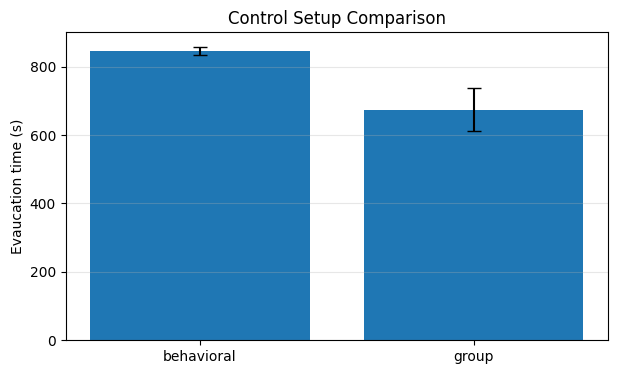

In [7]:
# Finally, plot the findings
plt.figure(figsize=(7,4))
plt.bar(summary['model'], summary['mean_evac_time_s'], yerr=summary['std_evac_time_s'], capsize=5)
plt.ylabel("Evaucation time (s)")
plt.title('Control Setup Comparison')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Experimental Plan (1 variable at a time)

Control setup followed NTU-style room evacuation

**Fixed Control Variables**
- `n_agents = 50`
- `door_width = 1.2` m
- `n_exits = 1`
- `room_size = 20.0` m (square room)
- `panic_speed = 1.5` m/s
- `max_steps = 2000`
- `n_runs = 3` seeds per setting

**Test cases**
| Test Case | Variable changed | Values tested | All other variables |
|---|---|---|---|
| TC0 | None (Control) | Control only | Fixed at control values |
| TC1 | `n_agents` | 50, 100, 200 | Control values |
| TC2 | `door_width` (m) | 1.0, 1.2, 1.6 | Control values |
| TC3 | `n_exits` | 1, 2, 3 | Control values |
| TC4 | `room_size` (m) | 16, 20, 24 | Control values |
| TC5 | `panic_speed` (m/s) | 1.5, 2.0, 3.0 | Control values |

In [8]:
# helper functions (reuse existing characteristic/group helpers if already defined)

def create_square_room_w_n_exits(size=20.0, n_exits=1, door_width=1.2, edge_margin=0.6):
    half = size / 2.0
    y_min, y_max = -half, half
    usable = (y_max - y_min) - 2 * edge_margin
    if n_exits * door_width >= usable:
        raise ValueError("Too many/wide exits for this room size.")

    centers = np.linspace(y_min + edge_margin + door_width/2, y_max - edge_margin - door_width/2, n_exits)
    gaps = [(c - door_width/2, c + door_width/2) for c in centers]

    walls = [
        [-half, half, -half, -half],   # bottom
        [-half, half, half, half],     # top
        [-half, -half, -half, half],   # left
    ]
    x = half
    cursor = y_min
    for g0, g1 in gaps:
        if g0 > cursor:
            walls.append([x, x, cursor, g0])
        cursor = g1
    if cursor < y_max:
        walls.append([x, x, cursor, y_max])
    return walls

def generate_random_positions(n_agents, room_size=20.0, margin=2.0):
    return np.random.uniform(
        low=-room_size/2 + margin,
        high=room_size/2 - margin,
        size=(n_agents, 2)
    )

def generate_characteristics(n_agents):
    age_categories = ["Young Adult", "Adult", "Middle Age"]
    genders = ["male", "female"]
    trait_levels = ["Low", "High"]
    chars = []
    for _ in range(n_agents):
        traits = [np.random.choice(trait_levels) for _ in range(5)]
        chars.append([np.random.choice(age_categories), np.random.choice(genders)] + traits)
    return chars

def create_initial_groups(positions, characteristics, behavior_grid_grouping_path, max_group_size=5, group_distance=1.2):
    import json
    with open(behavior_grid_grouping_path, "r", encoding="utf-8") as f:
        behavior_grid_group = json.load(f)

    prefs = []
    for age_cat, gender, o, c, e, a, n in characteristics:
        pref = "Solo"
        for b in behavior_grid_group:
            if (b["age_category"] == age_cat and b["gender"] == gender and
                b["traits"]["Openness"] == o and b["traits"]["Conscientiousness"] == c and
                b["traits"]["Extraversion"] == e and b["traits"]["Agreeableness"] == a and
                b["traits"]["Neuroticism"] == n):
                pref = b["group_preference"]
                break
        prefs.append(pref)

    n = len(positions)
    dmat = np.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=2)
    groups, used = [], set()
    for i in range(n):
        if i in used or prefs[i] == "Solo":
            continue
        cand = [i]
        for j in range(i + 1, n):
            if j not in used and prefs[j] == "Group" and dmat[i, j] < group_distance:
                cand.append(j)
        if len(cand) > 1:
            g = cand[:max_group_size]
            groups.append(g)
            used.update(g)
    return groups

In [9]:
# Unified runner (includes room_size + panic_speed)
def run_control_extended(
    model="baseline",
    n_agents=50,
    door_width=1.2,
    n_exits=1,
    room_size=20.0,
    panic_speed=1.5,   # requested variable
    tau=0.5,
    max_steps=2000,
    seed=42,
):
    np.random.seed(seed)
    model_key = {"behavioural": "behavioral"}.get(str(model).strip().lower(), str(model).strip().lower())

    pos0 = generate_random_positions(n_agents, room_size=room_size)
    final_goal = np.array([room_size/2 + 3.0, 0.0])
    goals = np.tile(final_goal, (n_agents, 1))
    obstacles = create_square_room_w_n_exits(size=room_size, n_exits=n_exits, door_width=door_width)

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = final_goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * panic_speed

    if model_key == "baseline":
        init = np.zeros((n_agents, 6), dtype=float)
        init[:, :2], init[:, 2:4], init[:, 4:6] = pos0, vel0, goals
        sim = psf.Simulator(
            init, groups=None, obstacles=obstacles, config_file=CONFIG_FILE,
            ped_state_class=psf.sceneforevacuation.PedStateEvacuation,
            env_state_class=psf.sceneforevacuation.EnvStateEvacuation
        )
    else:
        init = np.empty((n_agents, 14), dtype=object)
        init[:, :2], init[:, 2:4], init[:, 4:6], init[:, 6] = pos0, vel0, goals, tau
        chars = generate_characteristics(n_agents)
        for i, c in enumerate(chars):
            init[i, 7:] = c

        if model_key == "behavioral":
            sim = psf.SimulatorWithBehavior(
                init, groups=None, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        elif model_key == "group":
            groups = create_initial_groups(pos0, chars, GROUP_BEHAVIOR_FILE)
            sim = psf.SimulatorWithGroup(
                init, groups=groups, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        else:
            raise ValueError(f"Unknown model '{model}'")

    step = 0
    while step < max_steps and not np.all(sim.peds.escaped):
        sim.step(1)
        step += 1

    escaped = int(np.sum(sim.peds.escaped))
    complete = escaped == n_agents

    return {
        "model": model_key,
        "n_agents": n_agents,
        "door_width": door_width,
        "n_exits": n_exits,
        "room_size": room_size,
        "panic_speed": panic_speed,
        "steps": step if complete else np.nan,
        "evac_time_s": step * tau if complete else np.nan,
        "escaped_fraction": escaped / n_agents,
        "complete": complete,
    }

### Pilot Run (1 test case at a time)

The old one took too long and my IDE crashed (3 runs, 2000 steps max, all test cases at once). Decomposition into smaller steps, taking the percentage of escaped agents is required for better clarity & visualisation esp due to the time complexity of working with a large no. of agents, making the original run unfeasible

I have added the failed runs into a separate .py file to show the experimentation and trying new things

In [1]:
# now define TC0 to TC5. Pilot config - single test case per run
CONTROL = dict(n_agents=50, door_width=1.2, n_exits=1, room_size=20.0, panic_speed=1.5)
MODELS = ['baseline', 'behavioral', 'group']
N_RUNS = 3
MAX_STEPS = 800
TAU = 0.5  # seconds per step

TEST_CASES = {
    "TC0": {"var": "control",     "values": [None]},
    "TC1": {"var": "n_agents",    "values": [50, 100, 500]},
    "TC2": {"var": "door_width",  "values": [1.0, 1.2, 1.6]},
    "TC3": {"var": "n_exits",     "values": [1, 2, 3]},
    "TC4": {"var": "room_size",   "values": [16.0, 20.0, 24.0]},
    "TC5": {"var": "panic_speed", "values": [1.5, 2.0, 3.0]},
}

ACTIVE_TC = "TC1"  # change to TC2/TC3 & so on when needed

In [3]:
# define a new function for this pilot run
def run_timeseries(
    model="baseline",
    n_agents=50,
    door_width=1.2,
    n_exits=1,
    room_size=20.0,
    panic_speed=1.5,
    tau=0.5,
    max_steps=800,
    seed=42,
    keep_traj_every=20,   # record positions every N steps
):
    np.random.seed(seed)
    model_key = {"behavioural": "behavioral"}.get(str(model).strip().lower(), str(model).strip().lower())

    # --- geometry + init ---
    pos0 = generate_random_positions(n_agents, room_size=room_size)
    final_goal = np.array([room_size/2 + 3.0, 0.0])
    goals = np.tile(final_goal, (n_agents, 1))
    obstacles = create_square_room_w_n_exits(size=room_size, n_exits=n_exits, door_width=door_width)

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = final_goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * panic_speed

    if model_key == "baseline":
        init = np.zeros((n_agents, 6), dtype=float)
        init[:, :2], init[:, 2:4], init[:, 4:6] = pos0, vel0, goals
        sim = psf.Simulator(
            init, groups=None, obstacles=obstacles, config_file=CONFIG_FILE,
            ped_state_class=psf.sceneforevacuation.PedStateEvacuation,
            env_state_class=psf.sceneforevacuation.EnvStateEvacuation
        )
    else:
        init = np.empty((n_agents, 14), dtype=object)
        init[:, :2], init[:, 2:4], init[:, 4:6], init[:, 6] = pos0, vel0, goals, tau
        chars = generate_characteristics(n_agents)
        for i, c in enumerate(chars):
            init[i, 7:] = c

        if model_key == "behavioral":
            sim = psf.SimulatorWithBehavior(
                init, groups=None, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        elif model_key == "group":
            groups = create_initial_groups(pos0, chars, GROUP_BEHAVIOR_FILE)
            sim = psf.SimulatorWithGroup(
                init, groups=groups, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        else:
            raise ValueError(f"Unknown model '{model}'")

    # --- record over time ---
    curve_rows = []
    traj_rows = []

    for step in range(max_steps + 1):
        escaped = int(np.sum(sim.peds.escaped))
        curve_rows.append({
            "step": step,
            "time_s": step * tau,
            "escaped_count": escaped,
            "escaped_fraction": escaped / n_agents
        })

        if step % keep_traj_every == 0:
            p = sim.peds.pos()
            for i in range(n_agents):
                traj_rows.append({
                    "step": step,
                    "time_s": step * tau,
                    "agent_id": i,
                    "x": float(p[i, 0]),
                    "y": float(p[i, 1]),
                })

        if step < max_steps:
            sim.step(1)

    final = {
        "model": model_key,
        "n_agents": n_agents,
        "door_width": door_width,
        "n_exits": n_exits,
        "room_size": room_size,
        "panic_speed": panic_speed,
        "seed": seed,
        "escaped_count_final": curve_rows[-1]["escaped_count"],
        "escaped_fraction_final": curve_rows[-1]["escaped_fraction"],
    }

    return pd.DataFrame(curve_rows), pd.DataFrame(traj_rows), final

In [4]:
# we start w TC1
spec = TEST_CASES[ACTIVE_TC]
changed_var = spec["var"]
values = spec["values"]

all_curves, all_traj, all_final = [], [], []

for model in MODELS:
    for v in values:
        for run_i in range(N_RUNS):
            params = CONTROL.copy()
            if changed_var != "control":
                params[changed_var] = v

            df_curve, df_traj, final = run_timeseries(
                model=model,
                max_steps=MAX_STEPS,   # now 800
                tau=TAU,
                seed=1000 + run_i,
                **params
            )

            changed_value = "control" if changed_var == "control" else v

            df_curve["test_case"] = ACTIVE_TC
            df_curve["changed_var"] = changed_var
            df_curve["changed_value"] = changed_value
            df_curve["model"] = model
            df_curve["run"] = run_i + 1

            df_traj["test_case"] = ACTIVE_TC
            df_traj["changed_var"] = changed_var
            df_traj["changed_value"] = changed_value
            df_traj["model"] = model
            df_traj["run"] = run_i + 1

            final.update({
                "test_case": ACTIVE_TC,
                "changed_var": changed_var,
                "changed_value": changed_value,
                "run": run_i + 1,
            })

            all_curves.append(df_curve)
            all_traj.append(df_traj)
            all_final.append(final)

df_curves = pd.concat(all_curves, ignore_index=True)
df_traj = pd.concat(all_traj, ignore_index=True)
df_final = pd.DataFrame(all_final)

df_curves.to_csv(f"{ACTIVE_TC}_curves.csv", index=False)
df_traj.to_csv(f"{ACTIVE_TC}_traj.csv", index=False)
df_final.to_csv(f"{ACTIVE_TC}_final.csv", index=False)

NameError: name 'np' is not defined

### Pilot Protocol Update (Fast + Robust)

**Why we changed the metrics**
In earlier runs, `evac_time_s` became `NaN` whenever not all agents escaped before `max_steps`.
With a capped simulation (`max_steps=800`), this is common and makes plotting less useful.

So for pilot runs, we switch to **time-series evacuation metrics** that are always defined:
- `escaped_count(t)`: number of agents escaped at step `t`
- `escaped_fraction(t)`: escaped_count / total_agents at step `t`

These metrics let us compare models even when full evacuation is not reached.

**What changed**
- Keep `n_runs = 3` for each setting
- Set `max_steps = 800`
- Run **one test case at a time** (to reduce crash risk and runtime)
- Remove `complete=True/False` from analysis tables and plots
- Plot evacuation progress over time instead of only final evacuation time

**Time unit**
If `tau = 0.5`, then:
- `time_seconds = step * 0.5`

In [ ]:
# plot for the pilot run, no NaN issue
# Mean over 3 runs at each step
agg = (
    df_curves.groupby(["model", "changed_value", "step", "time_s"], as_index=False)
    .agg(
        escaped_count_mean=("escaped_count", "mean"),
        escaped_fraction_mean=("escaped_fraction", "mean")
    )
)

for v in sorted(agg["changed_value"].unique()):
    d = agg[agg["changed_value"] == v]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{TC_NAME}: {CHANGED_VAR}={v}", y=1.03)

    sns.lineplot(data=d, x="time_s", y="escaped_count_mean", hue="model", ax=axes[0])
    axes[0].set_title("Escaped Count vs Time")
    axes[0].set_ylabel("escaped_count")
    axes[0].grid(True, alpha=0.3)

    sns.lineplot(data=d, x="time_s", y="escaped_fraction_mean", hue="model", ax=axes[1], legend=False)
    axes[1].set_title("Escaped Fraction vs Time")
    axes[1].set_ylabel("escaped_fraction")
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# now we create a 'where agents go' trajectory view
# Plot sampled trajectories (lighter lines to avoid clutter)
sample_agents = 30
plot_df = df_traj[
    (df_traj["changed_value"] == VALUES[0]) &   # pick one value to view, e.g., 50
    (df_traj["model"] == "group") &             # pick one model to view
    (df_traj["run"] == 1)
].copy()

keep_ids = plot_df["agent_id"].drop_duplicates().sample(min(sample_agents, plot_df["agent_id"].nunique()), random_state=42)
plot_df = plot_df[plot_df["agent_id"].isin(keep_ids)]

plt.figure(figsize=(7,7))
for aid, g in plot_df.groupby("agent_id"):
    plt.plot(g["x"], g["y"], alpha=0.5, linewidth=1)

plt.title("Sample Agent Trajectories (where agents go)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()